# Titanic Survival Prediction Project

This project analyzes the Titanic passenger dataset to understand the factors that influenced survival and to build machine learning models capable of predicting whether a passenger survived or not.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report

In [49]:
df = pd.read_csv("Titanic_dataset.csv")
print(df.head())
print(df.tail())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

In [50]:
df.shape

(891, 12)

In [51]:
#1 understanding the data

## Data Understanding

In this section, we explore the dataset to understand its structure, variables, and basic characteristics. This includes examining the number of rows and columns, previewing the data, and identifying the types of variables present.

In [53]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [54]:
# Data Description

In [55]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [57]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Checking Missing Values

Before building models, it is important to identify missing values in the dataset. Missing data can affect model performance and therefore must be handled appropriately.

In [59]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [60]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [61]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [62]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

## Data Cleaning

In this step, we clean the dataset by removing unnecessary columns and handling missing values. Columns such as PassengerId, Name, Ticket, and Cabin are removed because they do not contribute significantly to predicting survival. Missing values in the Age and Embarked columns are filled using appropriate statistical methods.

In [64]:
df.drop('Cabin', axis=1, inplace=True)

In [65]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [66]:
df.drop(['PassengerId','Name','Ticket'], axis=1, inplace=True)

In [67]:
df['Sex'] = df['Sex'].map({'male':0,'female':1})

In [68]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

## Feature Engineering

Feature engineering helps create new meaningful variables that may improve model performance. In this project, we create a new feature called FamilySize, which combines the number of siblings/spouses and parents/children traveling with a passenger.

In [70]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [71]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,FamilySize
0,0,3,0,22.0,1,0,7.2500,False,True,2
1,1,1,1,38.0,1,0,71.2833,False,False,2
2,1,3,1,26.0,0,0,7.9250,False,True,1
3,1,1,1,35.0,1,0,53.1000,False,True,2
4,0,3,0,35.0,0,0,8.0500,False,True,1


In [72]:
df.drop(['SibSp','Parch'], axis=1, inplace=True)

In [73]:
df.describe()

,Survived,Pclass,Sex,Age,Fare,FamilySize
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208,1.904602
std,0.486592,0.836071,0.477990,13.019697,49.693429,1.613459
min,0.000000,1.000000,0.000000,0.420000,0.000000,1.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400,1.000000
50%,0.000000,3.000000,0.000000,28.000000,14.454200,1.000000
75%,1.000000,3.000000,1.000000,35.000000,31.000000,2.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200,11.000000


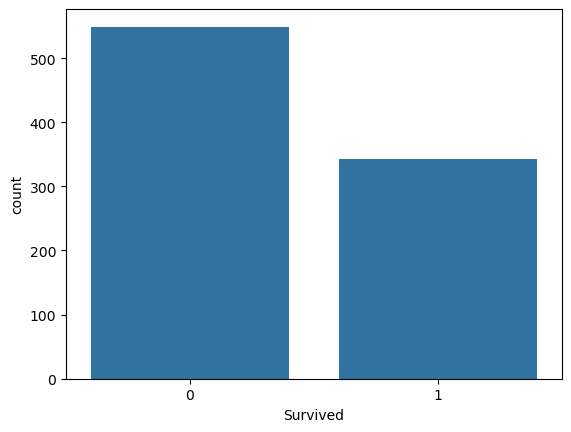

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', data=df)
plt.show()

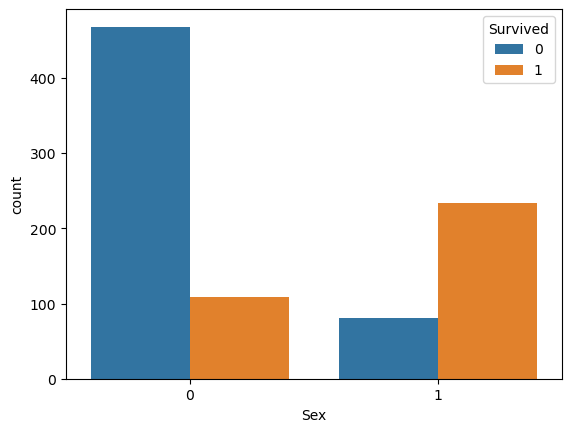

In [75]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

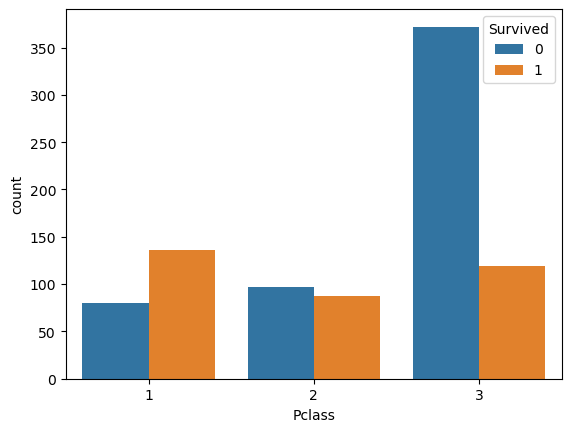

In [76]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

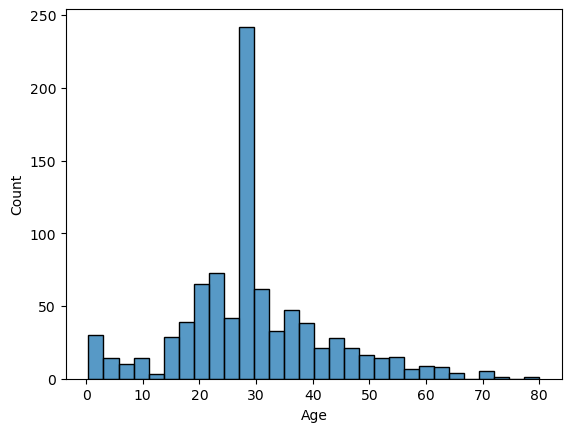

In [77]:
sns.histplot(df['Age'], bins=30)
plt.show()

In [78]:
df_numeric = df.select_dtypes(include=['number'])

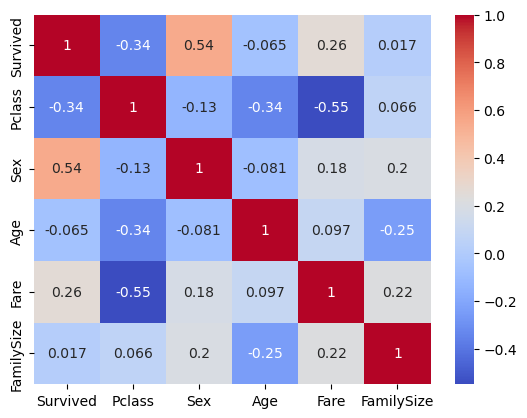

In [79]:
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.show()

## Data Preparation

To train machine learning models, the dataset is divided into features (X) and the target variable (y). The target variable is Survived, which indicates whether a passenger survived the disaster.

In [82]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train-Test Split

The dataset is split into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

In [85]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [86]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


In [87]:
X = df.drop('Survived', axis=1)
y = df['Survived']

## Model Training

Several machine learning algorithms are tested in order to determine which model performs best for predicting passenger survival.

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [91]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

## Model Evaluation

The performance of each model is evaluated using accuracy score. Accuracy measures the percentage of correct predictions made by the model.

In [92]:
from sklearn.metrics import accuracy_score

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, predictions)
    
    print(name, "Accuracy:", accuracy)

Logistic Regression Accuracy: 0.8044692737430168
Decision Tree Accuracy: 0.7821229050279329
Random Forest Accuracy: 0.8268156424581006
KNN Accuracy: 0.7206703910614525
SVM Accuracy: 0.659217877094972


## Model Evaluation

In this section, the trained model is evaluated using accuracy, precision, recall, and F1-score. A confusion matrix is also used to visualize the performance of the model.

In [96]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.64      0.94      0.76       105
           1       0.76      0.26      0.38        74

    accuracy                           0.66       179
   macro avg       0.70      0.60      0.57       179
weighted avg       0.69      0.66      0.61       179



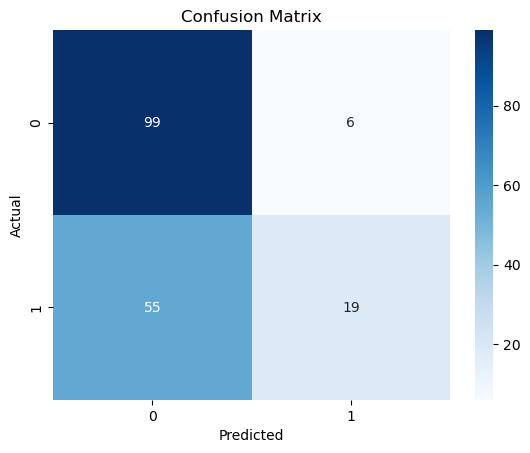

In [97]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Final Conclusion

In this project, we analyzed the Titanic dataset to predict passenger survival using machine learning techniques.

First, the dataset was explored to understand its structure and identify missing values. Data preprocessing was then performed by handling missing values, removing irrelevant columns, and converting categorical variables into numerical format.

Feature engineering was also applied by creating a new variable called **FamilySize**, which combines the number of siblings/spouses and parents/children traveling with each passenger.

Several machine learning models were trained, including Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM). The models were evaluated using different performance metrics such as **accuracy, precision, recall, and F1-score**.

A **confusion matrix** was also used to visualize the model's prediction results.

Among the models tested, **Random Forest achieved the highest accuracy**, making it the best-performing model for this dataset.

This project demonstrates the importance of data preprocessing, feature engineering, and model evaluation when building machine learning systems.